In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import csv
import re
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import torch
from torchvision import datasets, transforms
from tqdm import tqdm
import numpy as np
import random
from itertools import combinations
from collections import defaultdict
from sklearn.decomposition import PCA
from PIL import Image
import seaborn as sns
import matplotlib.image as mpimg



import src.architectures.networkArchitectures as netArch
from src.robustness.general_classes import ModelBridge
from src.robustness.milp_functions import *
from src.architectures.networkArchitectures import networkRegistry
from src.robustness.exactRobustness import exactRobustness
from src.robustness.fastLin import fastLin
from src.testing.networkTesting import testNetwork
from src.training.networkTraining import trainNetwork, saveNetwork
from src.utils.extractParams import extractParams
from src.utils.loadNetwork import loadNetwork

In [2]:
images_dir = Path("generated_images/Exp3MultimodelGeneratedImages/")
results_dir = Path("results/")
images_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)
classes_to_generate = (0, 1, 3)
INCLUDE_MISPREDICTED = False
df_exp1 = pd.read_csv("results/Exp1FastLinRobustnessResults.csv") 

In [3]:
numberOfRuns = 100  # Currently the number of images to TRY to generate
timeLimit = 300

som_mode = "independent"
csv_path = results_dir / "Exp3MultiModelGenerationResults.csv"

computed_pairs = set()
if csv_path.exists():
    df_computed = pd.read_csv(csv_path)
    computed_pairs = set(
        tuple(sorted(pair))
        for pair in zip(df_computed["network1"], df_computed["network2"])
    )

neededRuns = numberOfRuns - len(computed_pairs)

network_names = []
for networkName, entry in netArch.networkRegistry.items():
    if "big" in entry.tags:
        continue
    else:  network_names.append(networkName)

all_possible_pairs = {tuple(sorted(pair)) for pair in combinations(network_names, 2)}
remaining_pairs = all_possible_pairs - computed_pairs
selected_pairs = random.sample(list(remaining_pairs), min(neededRuns, len(all_possible_pairs)))

with csv_path.open(mode="a", newline="") as file:
    writer = csv.writer(file)
    if csv_path.stat().st_size == 0:
        writer.writerow(["network1", "network2", "target_class", "mode", "obj_val", "finishedSearch"])

    for net1_name, net2_name in selected_pairs:
        target_cls = random.choice(classes_to_generate)
        print(f"\n--- Generating MultiModel Sample: {net1_name} & {net2_name} | Class: {target_cls} ---")

        try:
            multimodel = MultiModel((784,), time_limit = timeLimit)
            network_pair_pt = []
            for name in [net1_name, net2_name]:
                NetClass = netArch.networkRegistry[name].NetworkClass
                model = NetClass()
                model.load_state_dict(torch.load(f'networks/{name}.pth', map_location='cpu'))
                model.eval()
                network_pair_pt.append(model)
            
            multimodel.add_networks(network_pair_pt)
            image, obj_val = generate_multi_model_input(multimodel, target_cls, mode=som_mode)

            if image is not None:
                finishedSearch = True
                img_filename = f"{net1_name}_{net2_name}_{target_cls}_{som_mode.replace(' ', '_')}.png"
                img_2d = image.reshape(28, 28)
                img_uint8 = (img_2d * 255).astype(np.uint8)
                Image.fromarray(img_uint8, mode='L').save(images_dir / img_filename)
                writer.writerow([net1_name, net2_name, target_cls, som_mode, obj_val, finishedSearch])
                file.flush()
                print("Optimal solution found")
            else:
                finishedSearch = False
                obj_val = 0
                writer.writerow([net1_name, net2_name, target_cls, som_mode, obj_val, finishedSearch])
                file.flush()
                print("Optimal solution not found")

        except Exception as e:
            print(f"  [Error]: {e}")
        finally:
            if hasattr(multimodel, 'g_model'):
                multimodel.g_model.dispose()


--- Generating MultiModel Sample: Dense2x35 & Dense2x45 | Class: 1 ---
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2765639
Academic license 2765639 - for non-commercial use only - registered to sa___@kth.se
Set parameter TimeLimit to value 300
Set parameter TimeLimit to value 300
Optimal solution not found

--- Generating MultiModel Sample: Dense2x45 & Dense3x20 | Class: 1 ---
Set parameter TimeLimit to value 300
Set parameter TimeLimit to value 300
Optimal solution not found

--- Generating MultiModel Sample: Dense2x45 & Dense5x20 | Class: 1 ---
Set parameter TimeLimit to value 300
Set parameter TimeLimit to value 300
Optimal solution not found

--- Generating MultiModel Sample: Dense2x30 & Dense2x40 | Class: 0 ---
Set parameter TimeLimit to value 300
Set parameter TimeLimit to value 300
Optimal solution found

--- Generating MultiModel Sample: Dense1x20 & Dense1x55 | Class: 0 ---
Set parameter TimeLimit to value 300
Set parameter TimeLimit to v

In [4]:
# --- Fast-Lin Test ---
filePath = results_dir / "Exp3FastLinOnMultiModelSamples.csv"
pNorm = 1 

computed_tests = set()
if filePath.exists():
    with filePath.open(mode="r") as f:
        reader = csv.reader(f)
        next(reader, None)
        for row in reader:
            if row: computed_tests.add((row[0], row[5])) # (TestingNet, Filename)

with filePath.open(mode="a", newline="") as file:
    writer = csv.writer(file)
    if filePath.stat().st_size == 0:
        writer.writerow(["testing_network", "gen_net1", "gen_net2", "target_class", "predicted_class", "mode", "filename", "fastlin_eps"])

    image_files = [f for f in os.listdir(images_dir) if f.endswith(".png")]

    for networkName in netArch.networkRegistry.keys():
        NetworkClass = netArch.networkRegistry[networkName].NetworkClass
        test_net = NetworkClass()
        test_net.load_state_dict(torch.load(f'networks/{networkName}.pth', map_location='cpu'))
        test_net.eval()
        
        params = extractParams(network=test_net, inputShape=(1, 28, 28))
        weights, biases = [W for W, _ in params], [b for _, b in params]

        for img_name in tqdm(image_files, desc=f"Testing {networkName}"):
            if (networkName, img_name) in computed_tests: continue

            try:
                parts = img_name.replace(".png", "").split("_")
                n1, n2, t_cls, s_mode = parts[0], parts[1], int(parts[2]), "_".join(parts[3:])
                
                img = Image.open(images_dir / img_name).convert('L')  # ensure grayscale
                x0 = np.array(img).astype(np.float32).flatten() / 255.0
                #x0 = plt.imread(images_dir / img_name).flatten().astype(np.float32)
                
                img_torch = torch.from_numpy(x0).unsqueeze(0)
                with torch.no_grad():
                    pred_cls = torch.argmax(test_net(img_torch), dim=1).item()

                targetClasses = [c for c in range(10) if c != pred_cls]
                eps, _, _ = fastLin(weights=weights, biases=biases, x0=x0, pNorm=pNorm, 
                                    epsilon0=10, originalClass=pred_cls, 
                                    targetClasses=targetClasses, tolerance=0.005)

                writer.writerow([networkName, n1, n2, t_cls, pred_cls, s_mode, img_name, eps])
                file.flush()
            except Exception as e:
                print(f" Error {img_name}: {e}")

Testing Dense6x70: 100%|██████████| 76/76 [00:43<00:00,  1.74it/s]


In [3]:
# 1. Load Data
df_exp3 = pd.read_csv("results/Exp3FastLinOnMultiModelSamples.csv")
df_exp2 = pd.read_csv("results/Exp2FastLinOnGeneratedSamples.csv")
df_exp1 = pd.read_csv("results/Exp1FastLinRobustnessResults.csv")

# 2. Identify the "Generator Pool" from Experiment 3
# Only use networks from Exp 2 that are actually part of the MultiModel pairs
multimodel_nets = set(df_exp3['gen_net1'].unique()) | set(df_exp3['gen_net2'].unique())
df_exp2_filtered = df_exp2[df_exp2['generating_network'].isin(multimodel_nets)].copy()

# 3. Setup Prediction Filter
if not INCLUDE_MISPREDICTED:
    df_exp3 = df_exp3[df_exp3['target_class'] == df_exp3['predicted_class']].copy()
    df_exp2_filtered = df_exp2_filtered[df_exp2_filtered['target_class'] == df_exp2_filtered['predicted_class']].copy()

# 4. Calculate Baselines and Transfer Metrics
mnist_means = df_exp1.groupby('label')['epsilon'].mean()

# Filtered Exp 2: Self vs Transfer
df_exp2_filtered['is_self'] = df_exp2_filtered['testing_network'] == df_exp2_filtered['generating_network']
exp2_self_means = df_exp2_filtered[df_exp2_filtered['is_self']].groupby('target_class')['fastlin_eps'].mean()
exp2_transfer_means = df_exp2_filtered[~df_exp2_filtered['is_self']].groupby('target_class')['fastlin_eps'].mean()

# Exp 3: Shared vs Transfer
df_exp3['is_shared'] = (df_exp3['testing_network'] == df_exp3['gen_net1']) | \
                       (df_exp3['testing_network'] == df_exp3['gen_net2'])

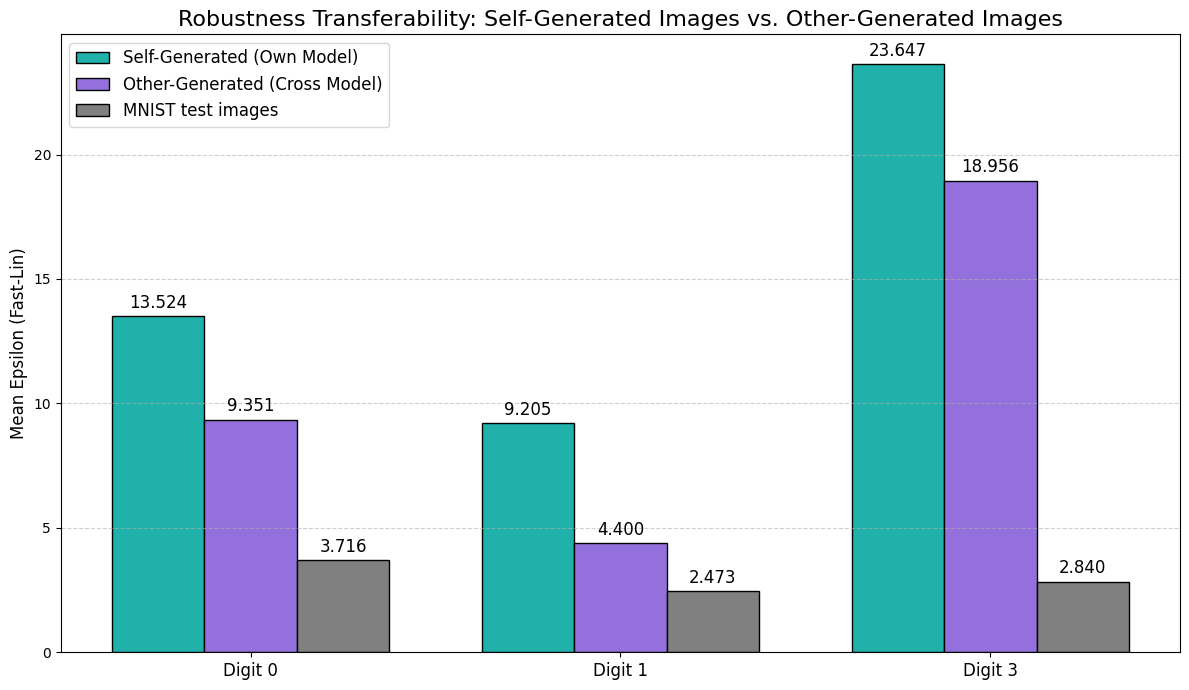

In [31]:
# --- MultiModel & Exp 2 Transferability Analysis (Filtered for Shared Generators) ---

mm_shared_means = df_exp3[df_exp3['is_shared']].groupby('target_class')['fastlin_eps'].mean()
mm_transfer_means = df_exp3[~df_exp3['is_shared']].groupby('target_class')['fastlin_eps'].mean()

# 5. Prepare Plotting Data
target_classes = sorted(df_exp3['target_class'].unique())
plot_data = []
for c in target_classes:
    plot_data.append({
        'Class': f"Digit {c}",    
        'Self-Generated': mm_shared_means.get(c, 0),
        'Other-Generated': mm_transfer_means.get(c, 0),
        'MNIST Baseline': mnist_means.get(c, 0)
    })
plot_df = pd.DataFrame(plot_data).set_index('Class')

# Plotting
x = np.arange(len(target_classes))
width = 0.25  # Width of each grouped bar

fig, ax = plt.subplots(figsize=(12, 7))

rects1 = ax.bar(x - width, plot_df['Self-Generated'], width, label='Self-Generated (Own Model)', color='lightseagreen', edgecolor = "black")
rects2 = ax.bar(x, plot_df['Other-Generated'], width, label='Other-Generated (Cross Model)', color='mediumpurple', edgecolor = "black")
rects3 = ax.bar(x + width, plot_df['MNIST Baseline'], width, label='MNIST test images', color='grey', edgecolor = "black")

# Styling
ax.set_ylabel('Mean Epsilon (Fast-Lin)', fontsize=12)
ax.set_title('Robustness Transferability: Self-Generated Images vs. Other-Generated Images', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, fontsize = 12)
ax.legend(fontsize='large', loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Helper function to add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=12)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
                  
plt.tight_layout()
plt.show()

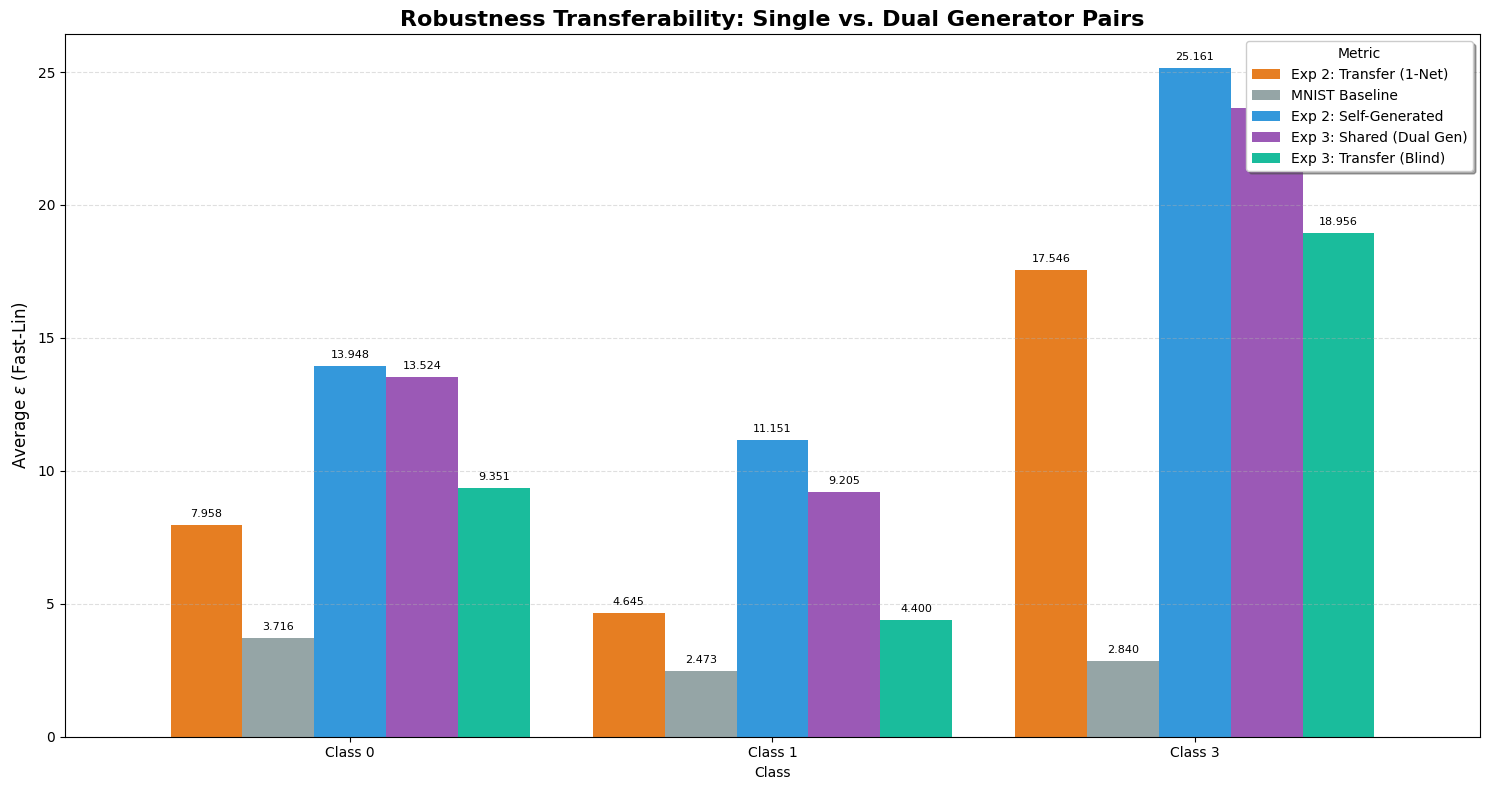

In [29]:
# --- MultiModel & Exp 2 Transferability Analysis (Filtered for Shared Generators) ---



mm_shared_means = df_exp3[df_exp3['is_shared']].groupby('target_class')['fastlin_eps'].mean()
mm_transfer_means = df_exp3[~df_exp3['is_shared']].groupby('target_class')['fastlin_eps'].mean()

# 5. Prepare Plotting Data
target_classes = sorted(df_exp3['target_class'].unique())
plot_data = []
for c in target_classes:
    plot_data.append({
        'Class': f"Class {c}",
        'Exp 2: Transfer (1-Net)': exp2_transfer_means.get(c, 0),    # Leftmost
        'MNIST Baseline': mnist_means.get(c, 0),                    # 2nd Leftmost
        'Exp 2: Self-Generated': exp2_self_means.get(c, 0),         
        'Exp 3: Shared (Dual Gen)': mm_shared_means.get(c, 0),
        'Exp 3: Transfer (Blind)': mm_transfer_means.get(c, 0)
    })
plot_df = pd.DataFrame(plot_data).set_index('Class')

# 6. Plotting
colors = ['#e67e22', '#95a5a6', '#3498db', '#9b59b6', '#1abc9c']
ax = plot_df.plot(kind='bar', figsize=(15, 8), color=colors, width=0.85)

plt.title('Robustness Transferability: Single vs. Dual Generator Pairs', fontsize=16, fontweight='bold')
plt.ylabel('Average $\epsilon$ (Fast-Lin)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Metric", frameon=True, shadow=True, loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Add numeric labels to bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()

In [30]:
# --- Generate Average Samples ---
avg_images_dir = Path("generated_images/Exp3AvgGeneratedImages/")
avg_images_dir.mkdir(parents=True, exist_ok=True)

# 1. Average MNIST
mnist_train = datasets.MNIST('./data', train=True, download=True, transform=transforms.ToTensor())
for cls in classes_to_generate:
    indices = [i for i, (_, label) in enumerate(mnist_train) if label == cls]
    avg_img = torch.stack([mnist_train[i][0] for i in indices]).mean(dim=0).squeeze().numpy()

    img_2d = avg_img.reshape(28, 28)
    img_uint8 = (img_2d * 255).astype(np.uint8)
    Image.fromarray(img_uint8, mode='L').save(avg_images_dir / f"Avg_MNIST_{cls}.png")

    #plt.imsave(avg_images_dir / f"Avg_MNIST_{cls}.png", avg_img, cmap='gray')

# 2. Average Exp 2 Generations
df_exp2 = pd.read_csv("results/Exp2FastLinOnGeneratedSamples.csv")
exp2_dir = Path("generated_images/Exp2GeneratedImages/")
for cls in classes_to_generate:
    files = df_exp2[df_exp2['target_class'] == cls]['filename'].unique()
    imgs = [
        np.array(Image.open(exp2_dir / f).convert("L"), dtype=np.float32) / 255.0
        for f in files
        if f.endswith(".png") and (exp2_dir / f).exists()]
    #imgs = [plt.imread(exp2_dir / f)[:,:,0] if f.endswith('.png') else plt.imread(exp2_dir / f) for f in files if (exp2_dir / f).exists()]
    if imgs:
        img = np.mean(imgs, axis=0)
        img_2d = img.reshape(28, 28)
        img_uint8 = (img_2d * 255).astype(np.uint8)
        Image.fromarray(img_uint8, mode='L').save(avg_images_dir / f"Avg_Exp2_{cls}.png")        
        #plt.imsave(avg_images_dir / f"Avg_Exp2_{cls}.png", np.mean(imgs, axis=0), cmap='gray')

Testing Average Samples on Dense6x70: 100%|██████████| 6/6 [00:03<00:00,  1.96it/s]


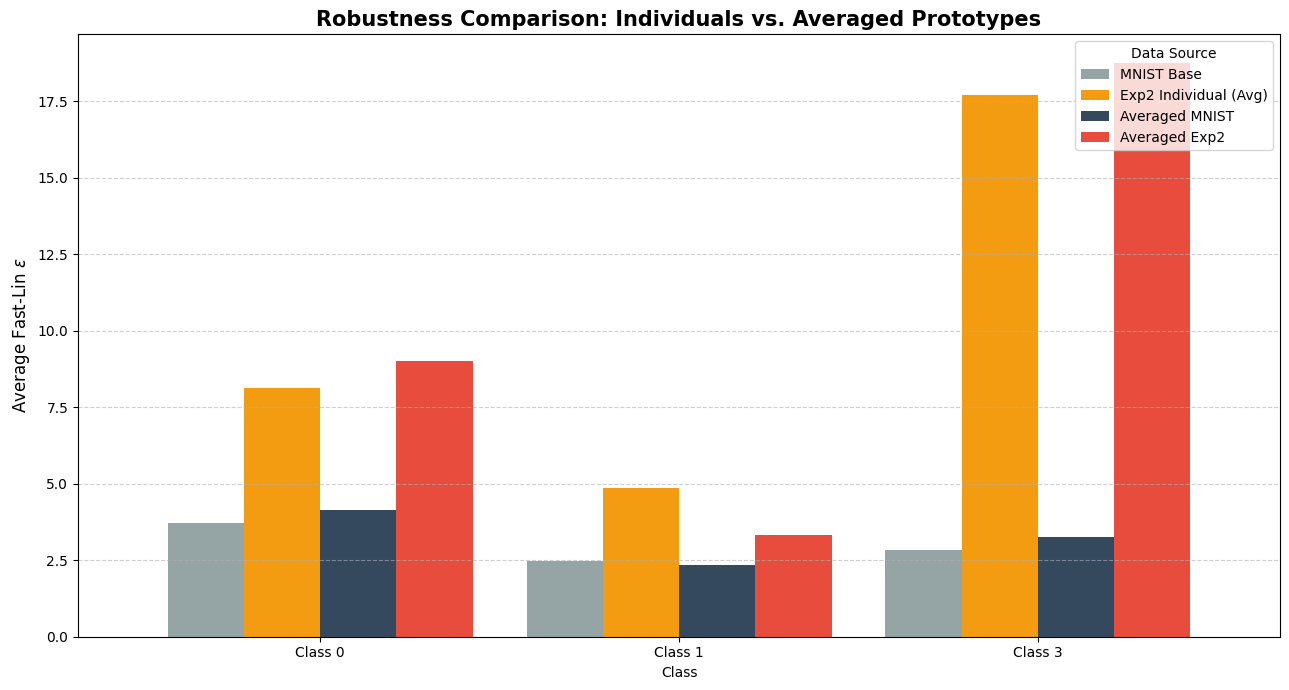

In [8]:
# --- 1. Test Averaged Samples ---
avg_results_path = results_dir / "Exp3FastLinOnAveragedSamples.csv"
pNorm = 1

computed_avg_tests = set()
if avg_results_path.exists():
    with avg_results_path.open(mode="r") as f:
        reader = csv.reader(f)
        next(reader, None)
        for row in reader:
            if row: computed_avg_tests.add((row[0], row[1]))

with avg_results_path.open(mode="a", newline="") as file:
    writer = csv.writer(file)
    if avg_results_path.stat().st_size == 0:
        writer.writerow(["testing_network", "filename", "source", "target_class", "predicted_class", "fastlin_eps"])

    avg_files = [f for f in os.listdir(avg_images_dir) if f.endswith(".png")]

    for networkName in netArch.networkRegistry.keys():
        test_net = netArch.networkRegistry[networkName].NetworkClass()
        test_net.load_state_dict(torch.load(f'networks/{networkName}.pth', map_location='cpu'))
        test_net.eval()
        
        params = extractParams(network=test_net, inputShape=(1, 28, 28))
        weights, biases = [W for W, _ in params], [b for _, b in params]

        for img_name in tqdm(avg_files, desc=f"Testing Average Samples on {networkName}"):
            if (networkName, img_name) in computed_avg_tests: continue

            img_raw = plt.imread(avg_images_dir / img_name)
            if img_raw.ndim == 3: img_raw = img_raw[:, :, 0]
            x0 = img_raw.flatten().astype(np.float32)

            parts = img_name.replace(".png", "").split("_")
            source, t_cls = parts[1], int(parts[2])
            
            img_torch = torch.from_numpy(x0).unsqueeze(0)
            with torch.no_grad():
                pred_cls = torch.argmax(test_net(img_torch), dim=1).item()

            eps, _, _ = fastLin(weights=weights, biases=biases, x0=x0, pNorm=pNorm, 
                                epsilon0=10, originalClass=pred_cls, 
                                targetClasses=[c for c in range(10) if c != pred_cls], tolerance=0.005)

            writer.writerow([networkName, img_name, source, t_cls, pred_cls, eps])
            file.flush()

# --- 2. Visualization ---
# Load Exp 3 results
df_avg = pd.read_csv(avg_results_path)
# Load Exp 2 results for the new comparison bar
df_exp2_raw = pd.read_csv("results/Exp2FastLinOnGeneratedSamples.csv")

if not INCLUDE_MISPREDICTED:
    df_avg = df_avg[df_avg['target_class'] == df_avg['predicted_class']].copy()
    df_exp2_raw = df_exp2_raw[df_exp2_raw['target_class'] == df_exp2_raw['predicted_class']].copy()

# Averages for Exp 3
avg_mnist_means = df_avg[df_avg['source'] == 'MNIST'].groupby('target_class')['fastlin_eps'].mean()
avg_exp2_means = df_avg[df_avg['source'] == 'Exp2'].groupby('target_class')['fastlin_eps'].mean()

# Average robustness for Exp 2 (averaged over all networks and SOM modes)
exp2_individual_means = df_exp2_raw.groupby('target_class')['fastlin_eps'].mean()

target_classes = sorted(df_avg['target_class'].unique())
plot_df_avg = pd.DataFrame([{
    'Class': f"Class {c}",
    'MNIST Base': df_exp1.groupby('label')['epsilon'].mean().get(c, 0),
    'Exp2 Individual (Avg)': exp2_individual_means.get(c, 0),
    'Averaged MNIST': avg_mnist_means.get(c, 0),
    'Averaged Exp2': avg_exp2_means.get(c, 0)
} for c in target_classes]).set_index('Class')

# Plotting with a distinct color palette
colors = ['#95a5a6', '#f39c12', '#34495e', '#e74c3c']
ax = plot_df_avg.plot(kind='bar', figsize=(13, 7), color=colors, width=0.85)

plt.title('Robustness Comparison: Individuals vs. Averaged Prototypes', fontsize=15, fontweight='bold')
plt.ylabel('Average Fast-Lin $\epsilon$', fontsize=12)
plt.legend(title="Data Source", frameon=True, loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

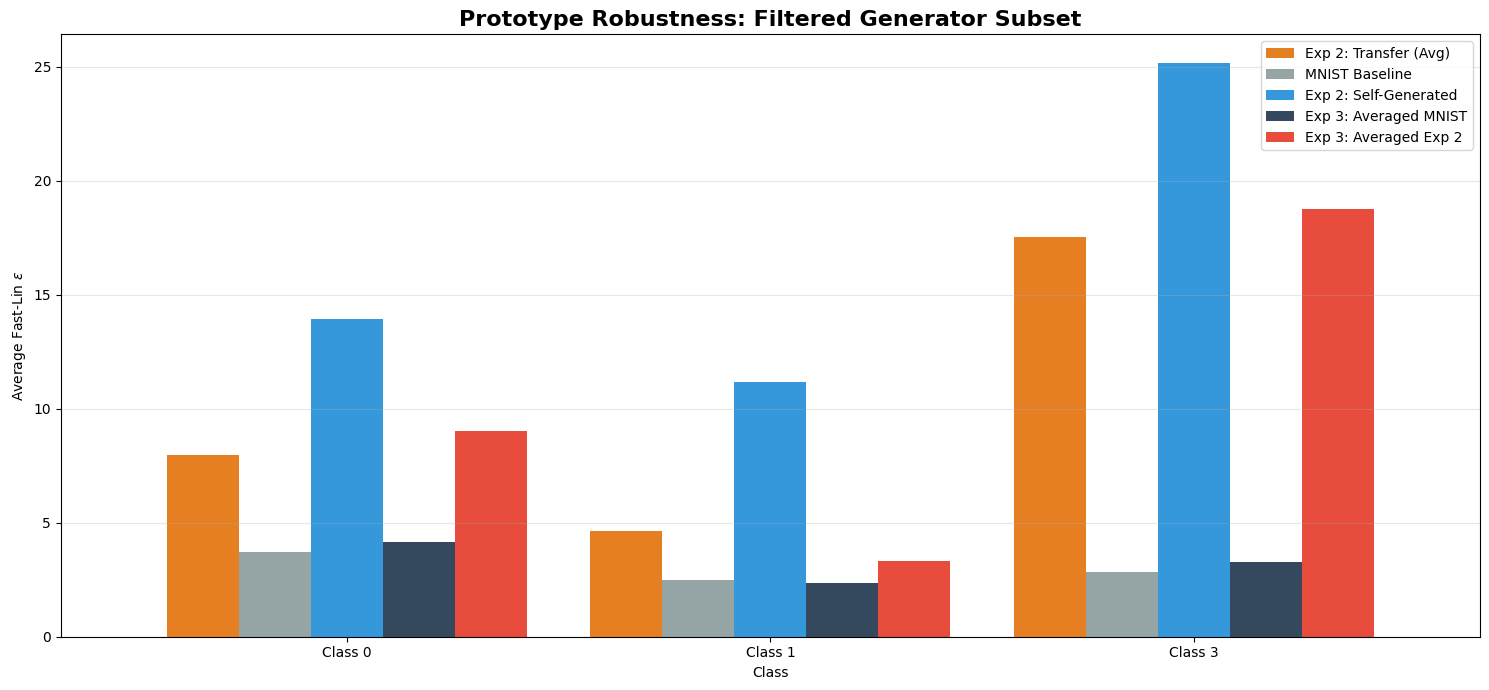

In [9]:
# --- Visualize Averaged Results (Filtered Generators) ---
df_avg = pd.read_csv("results/Exp3FastLinOnAveragedSamples.csv")

if not INCLUDE_MISPREDICTED:
    df_avg = df_avg[df_avg['target_class'] == df_avg['predicted_class']].copy()

avg_mnist_means = df_avg[df_avg['source'] == 'MNIST'].groupby('target_class')['fastlin_eps'].mean()
avg_exp2_means = df_avg[df_avg['source'] == 'Exp2'].groupby('target_class')['fastlin_eps'].mean()

plot_df_avg = pd.DataFrame([{
    'Class': f"Class {c}",
    'Exp 2: Transfer (Avg)': exp2_transfer_means.get(c, 0),       # Leftmost
    'MNIST Baseline': mnist_means.get(c, 0),                      # 2nd Leftmost
    'Exp 2: Self-Generated': exp2_self_means.get(c, 0),
    'Exp 3: Averaged MNIST': avg_mnist_means.get(c, 0),
    'Exp 3: Averaged Exp 2': avg_exp2_means.get(c, 0)
} for c in target_classes]).set_index('Class')

colors_avg = ['#e67e22', '#95a5a6', '#3498db', '#34495e', '#e74c3c']
plot_df_avg.plot(kind='bar', figsize=(15, 7), color=colors_avg, width=0.85)

plt.title('Prototype Robustness: Filtered Generator Subset', fontsize=16, fontweight='bold')
plt.ylabel('Average Fast-Lin $\epsilon$')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [10]:
from sklearn.decomposition import PCA
from PIL import Image

# --- PCA Generation (MNIST & Exp 2) ---
pca_images_dir = Path("generated_images/Exp3PCAGeneratedImages/")
pca_images_dir.mkdir(parents=True, exist_ok=True)
exp2_source_dir = Path("generated_images/Exp2GeneratedImages/") 

# Use the classes defined in your experiment (e.g., [0, 1, 3])
for cls in classes_to_generate:
    # A. PCA on MNIST
    mnist_indices = [i for i, (_, label) in enumerate(mnist_train) if label == cls]
    mnist_data = torch.stack([mnist_train[i][0] for i in mnist_indices]).view(len(mnist_indices), -1).numpy()
    pca_mnist = PCA(n_components=10).fit(mnist_data)
    
    # B. PCA on Exp 2 Generated Images
    exp2_files = [f for f in os.listdir(exp2_source_dir) if f.endswith(".png") and f"_{cls}_" in f]
    if exp2_files:
        exp2_list = []
        for f in exp2_files:
            img = Image.open(exp2_source_dir / f).convert('L')
            exp2_list.append(np.array(img).flatten() / 255.0)
        exp2_data = np.array(exp2_list)
        pca_exp2 = PCA(n_components=10).fit(exp2_data)
    else:
        pca_exp2 = None

    # C. Generate 5 variations for each
    for i in range(5):
        factor = (i - 2) * 2.5 
        # MNIST-PCA
        img_mnist = np.clip(pca_mnist.mean_ + factor * pca_mnist.components_[0], 0, 1).reshape(28, 28)
        plt.imsave(pca_images_dir / f"PCA_MNIST_{cls}_var{i}.png", img_mnist, cmap='gray')
        # Exp2-PCA
        if pca_exp2 is not None:
            img_exp2 = np.clip(pca_exp2.mean_ + factor * pca_exp2.components_[0], 0, 1).reshape(28, 28)
            plt.imsave(pca_images_dir / f"PCA_Exp2_{cls}_var{i}.png", img_exp2, cmap='gray')

print(f"PCA images generated in {pca_images_dir}")

PCA images generated in generated_images\Exp3PCAGeneratedImages


In [11]:
# --- 1. Test PCA Samples ---
pca_results_path = results_dir / "Exp3FastLinOnPCASamples.csv"

# Optional: Delete the file if it has the old format (missing 'source')
if pca_results_path.exists():
    temp_df = pd.read_csv(pca_results_path)
    if 'source' not in temp_df.columns:
        print("Old CSV format detected. Deleting to recreate with 'source' column...")
        pca_results_path.unlink()

computed_pca_tests = set()
if pca_results_path.exists():
    with pca_results_path.open(mode="r") as f:
        reader = csv.reader(f)
        next(reader, None)
        for row in reader:
            if row: computed_pca_tests.add((row[0], row[1]))

with pca_results_path.open(mode="a", newline="") as file:
    writer = csv.writer(file)
    if pca_results_path.stat().st_size == 0:
        # Header NOW includes 'source'
        writer.writerow(["testing_network", "filename", "source", "target_class", "variation", "predicted_class", "fastlin_eps"])

    pca_files = [f for f in os.listdir(pca_images_dir) if f.endswith(".png")]

    for networkName in netArch.networkRegistry.keys():
        test_net = netArch.networkRegistry[networkName].NetworkClass()
        test_net.load_state_dict(torch.load(f'networks/{networkName}.pth', map_location='cpu'))
        test_net.eval()
        params = extractParams(network=test_net, inputShape=(1, 28, 28))
        weights, biases = [W for W, _ in params], [b for _, b in params]

        for img_name in tqdm(pca_files, desc=f"Testing PCA Samples on {networkName}"):
            if (networkName, img_name) in computed_pca_tests: continue

            img = Image.open(pca_images_dir / img_name).convert('L')
            x0 = np.array(img).astype(np.float32).flatten() / 255.0

            # Filename parsing logic: PCA_{SOURCE}_{CLASS}_var{I}.png
            parts = img_name.replace(".png", "").split("_")
            source, t_cls, var_idx = parts[1], int(parts[2]), parts[3]
            
            img_torch = torch.from_numpy(x0).unsqueeze(0)
            with torch.no_grad():
                pred_cls = torch.argmax(test_net(img_torch), dim=1).item()

            eps, _, _ = fastLin(weights=weights, biases=biases, x0=x0, pNorm=1, 
                                epsilon0=10, originalClass=pred_cls, 
                                targetClasses=[c for c in range(10) if c != pred_cls], tolerance=0.005)

            # Write with 'source'
            writer.writerow([networkName, img_name, source, t_cls, var_idx, pred_cls, eps])
            file.flush()

Testing PCA Samples on Dense6x70: 100%|██████████| 30/30 [00:18<00:00,  1.61it/s]


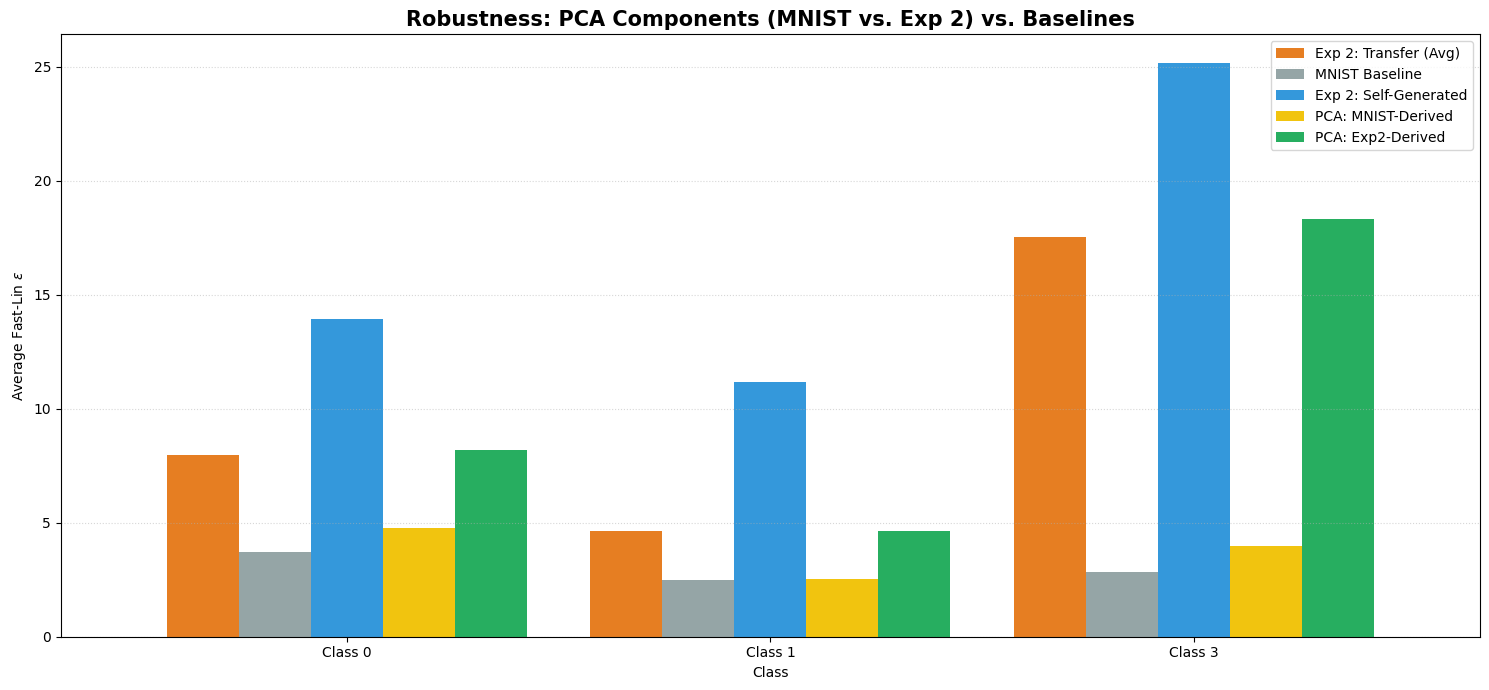

In [12]:
# --- 2. PCA Visualization ---
df_pca = pd.read_csv("results/Exp3FastLinOnPCASamples.csv")

if not INCLUDE_MISPREDICTED:
    df_pca = df_pca[df_pca['target_class'] == df_pca['predicted_class']].copy()

pca_mnist_means = df_pca[df_pca['source'] == 'MNIST'].groupby('target_class')['fastlin_eps'].mean()
pca_exp2_means = df_pca[df_pca['source'] == 'Exp2'].groupby('target_class')['fastlin_eps'].mean()
mnist_base = df_exp1.groupby('label')['epsilon'].mean()

plot_df_pca = pd.DataFrame([{
    'Class': f"Class {c}",
    'Exp 2: Transfer (Avg)': exp2_transfer_means.get(c, 0),
    'MNIST Baseline': mnist_base.get(c, 0),
    'Exp 2: Self-Generated': exp2_self_means.get(c, 0),
    'PCA: MNIST-Derived': pca_mnist_means.get(c, 0),
    'PCA: Exp2-Derived': pca_exp2_means.get(c, 0)
} for c in target_classes]).set_index('Class')

colors_pca = ['#e67e22', '#95a5a6', '#3498db', '#f1c40f', '#27ae60']
ax = plot_df_pca.plot(kind='bar', figsize=(15, 7), color=colors_pca, width=0.85)

plt.title('Robustness: PCA Components (MNIST vs. Exp 2) vs. Baselines', fontsize=15, fontweight='bold')
plt.ylabel('Average Fast-Lin $\epsilon$')
plt.xticks(rotation=0); plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend(loc='upper right', frameon=True); plt.tight_layout(); plt.show()

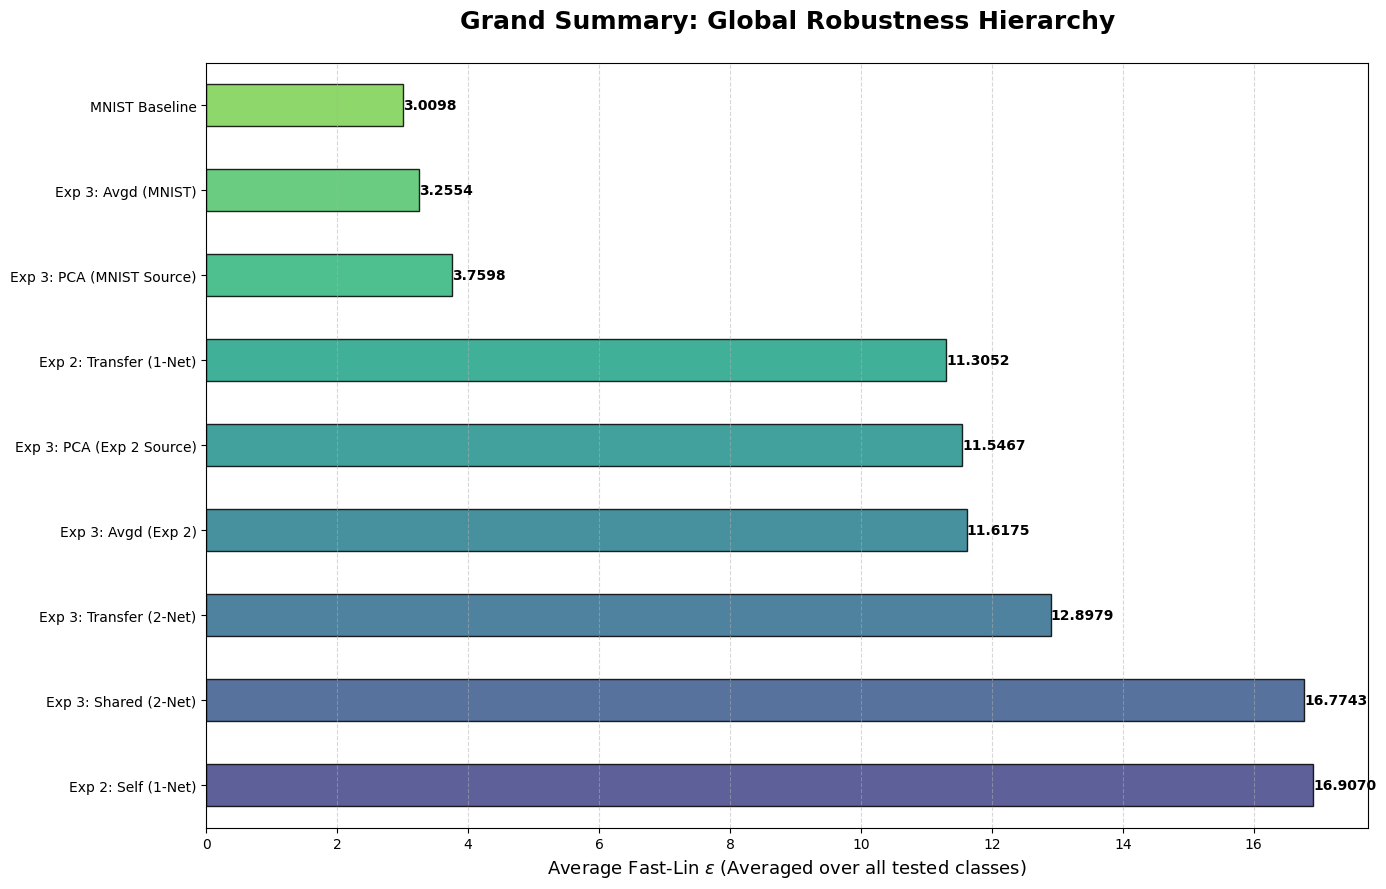

In [13]:
INCLUDE_MISPREDICTED = False


# --- Exp 3: Grand Summary (Global Averages) ---

# 1. Load All Data
df_exp1 = pd.read_csv("results/Exp1FastLinRobustnessResults.csv")
df_exp2 = pd.read_csv("results/Exp2FastLinOnGeneratedSamples.csv")
df_exp3_mm = pd.read_csv("results/Exp3FastLinOnMultiModelSamples.csv")
df_exp3_avg = pd.read_csv("results/Exp3FastLinOnAveragedSamples.csv")
df_exp3_pca = pd.read_csv("results/Exp3FastLinOnPCASamples.csv")

# 2. Filter for consistency (Only networks used in Experiment 3 pairs)
mm_nets = set(df_exp3_mm['gen_net1'].unique()) | set(df_exp3_mm['gen_net2'].unique())
df_exp2_f = df_exp2[df_exp2['generating_network'].isin(mm_nets)].copy()

# 3. Handle Mispredictions
if not INCLUDE_MISPREDICTED:
    df_exp2_f = df_exp2_f[df_exp2_f['target_class'] == df_exp2_f['predicted_class']]
    df_exp3_mm = df_exp3_mm[df_exp3_mm['target_class'] == df_exp3_mm['predicted_class']]
    df_exp3_avg = df_exp3_avg[df_exp3_avg['target_class'] == df_exp3_avg['predicted_class']]
    df_exp3_pca = df_exp3_pca[df_exp3_pca['target_class'] == df_exp3_pca['predicted_class']]

# 4. Calculate Global Averages
summary_data = {
    'MNIST Baseline': df_exp1['epsilon'].mean(),
    
    # Single-Model (Exp 2)
    'Exp 2: Self (1-Net)': df_exp2_f[df_exp2_f['testing_network'] == df_exp2_f['generating_network']]['fastlin_eps'].mean(),
    'Exp 2: Transfer (1-Net)': df_exp2_f[df_exp2_f['testing_network'] != df_exp2_f['generating_network']]['fastlin_eps'].mean(),
    
    # Multi-Model (Exp 3)
    'Exp 3: Shared (2-Net)': df_exp3_mm[(df_exp3_mm['testing_network'] == df_exp3_mm['gen_net1']) | 
                                      (df_exp3_mm['testing_network'] == df_exp3_mm['gen_net2'])]['fastlin_eps'].mean(),
    'Exp 3: Transfer (2-Net)': df_exp3_mm[~((df_exp3_mm['testing_network'] == df_exp3_mm['gen_net1']) | 
                                           (df_exp3_mm['testing_network'] == df_exp3_mm['gen_net2']))]['fastlin_eps'].mean(),
    
    # Processing (Exp 3 Prototypes)
    'Exp 3: Avgd (MNIST)': df_exp3_avg[df_exp3_avg['source'] == 'MNIST']['fastlin_eps'].mean(),
    'Exp 3: Avgd (Exp 2)': df_exp3_avg[df_exp3_avg['source'] == 'Exp2']['fastlin_eps'].mean(),
    
    # Processing (Exp 3 PCA) - Now split into both sources
    'Exp 3: PCA (MNIST Source)': df_exp3_pca[df_exp3_pca['source'] == 'MNIST']['fastlin_eps'].mean(),
    'Exp 3: PCA (Exp 2 Source)': df_exp3_pca[df_exp3_pca['source'] == 'Exp2']['fastlin_eps'].mean(),
}

# 5. Convert to Series and Sort
summary_series = pd.Series(summary_data).sort_values(ascending=False)

# 6. Plotting
plt.figure(figsize=(14, 9))
# Using a diverging colormap to distinguish high vs low robustness
colors = plt.cm.viridis(np.linspace(0.8, 0.2, len(summary_series)))[::-1] 
ax = summary_series.plot(kind='barh', color=colors, edgecolor='black', alpha=0.85)

plt.title('Grand Summary: Global Robustness Hierarchy', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Average Fast-Lin $\epsilon$ (Averaged over all tested classes)', fontsize=13)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add numeric values on the right of the bars
for i, v in enumerate(summary_series):
    if not np.isnan(v):
        ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

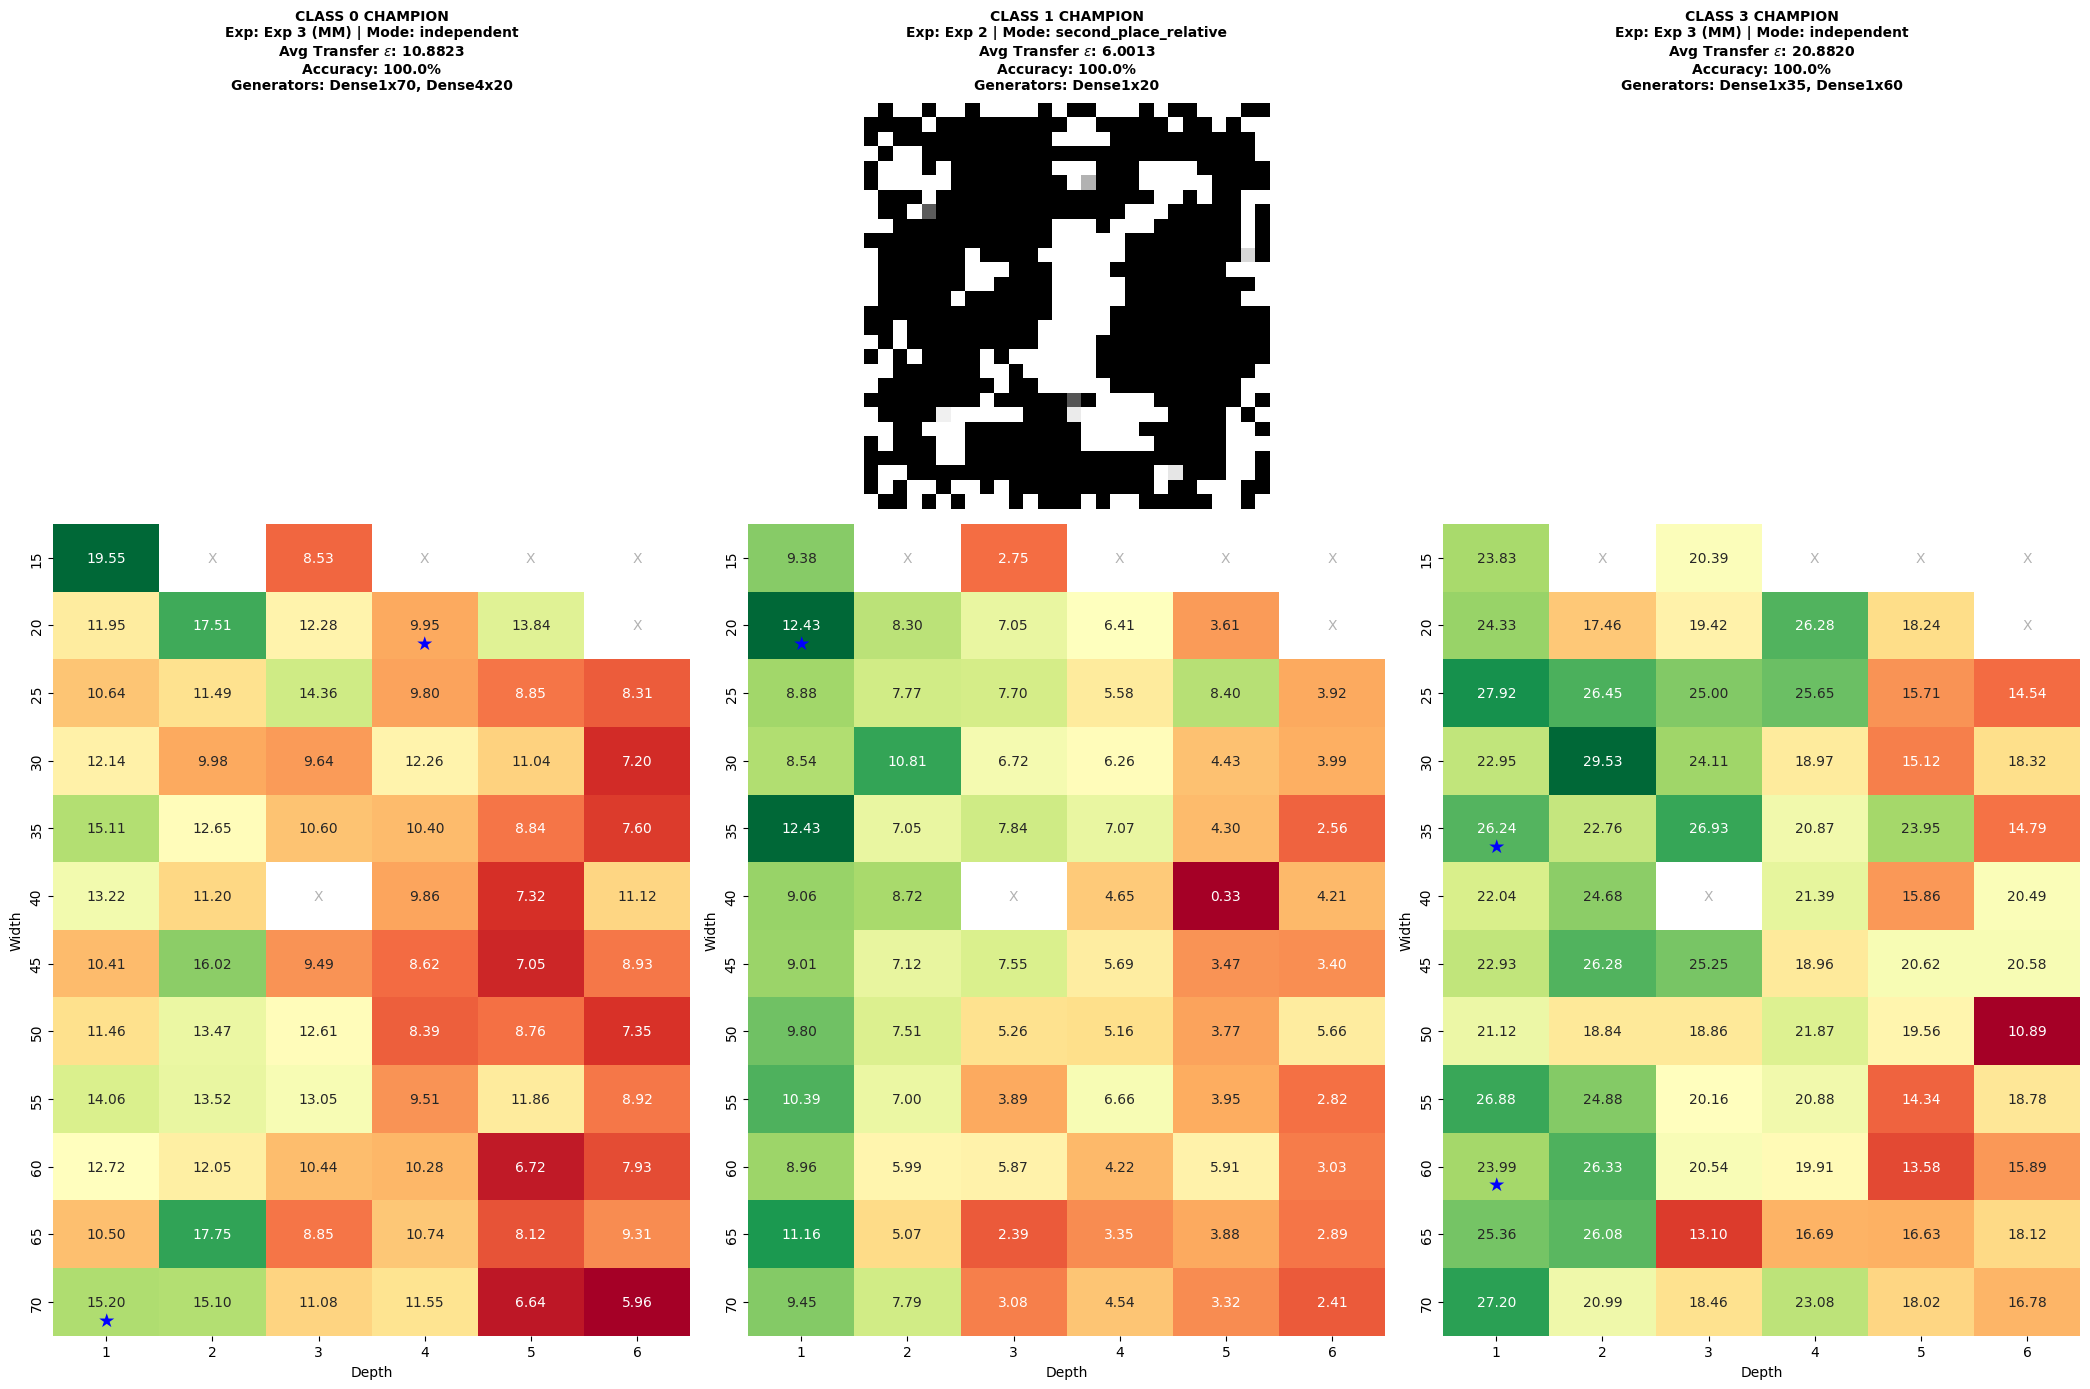

In [14]:
# ==========================================
# CONFIGURATION
# ==========================================
PENALIZE_MISCLASSIFIED = True  
INCLUDE_SELF_TESTS     = False 
MIN_ACCURACY_THRESHOLD = 0.0   
# ==========================================

def get_dims(name):
    """Parses W_D or XxY naming conventions."""
    m = re.search(r'W_?(\d+)_?D_?(\d+)', str(name), re.IGNORECASE)
    if m: return (int(m.group(1)), int(m.group(2)))
    m = re.search(r'(\d+)x(\d+)', str(name))
    if m: return (int(m.group(2)), int(m.group(1))) 
    return (None, None)

def load_and_preprocess(path):
    if not Path(path).exists(): return pd.DataFrame()
    df = pd.read_csv(path)
    if df.empty: return df
    
    # Identify epsilon column
    eps_col = 'fastlin_eps' if 'fastlin_eps' in df.columns else 'epsilon'
    
    # Standardize 'mode' column naming across different experiments
    if 'som_mode' in df.columns:
        df = df.rename(columns={'som_mode': 'mode'})
    
    # Force misclassified samples to 0
    if 'target_class' in df.columns and 'predicted_class' in df.columns:
        df.loc[df['target_class'] != df['predicted_class'], eps_col] = 0
    
    # Option to ignore 0s in the average calculation (Version 1 behavior)
    if not PENALIZE_MISCLASSIFIED:
        df = df[df['target_class'] == df['predicted_class']]
        
    return df

# 1. Load All Data
dfs = {
    'MNIST':  load_and_preprocess("results/Exp1FastLinOnMNIST.csv"),
    'Exp 2':  load_and_preprocess("results/Exp2FastLinOnGeneratedSamples.csv"),
    'Exp 3 (MM)': load_and_preprocess("results/Exp3FastLinOnMultiModelSamples.csv"),
    'Exp 3 (Avg)': load_and_preprocess("results/Exp3FastLinOnAveragedSamples.csv"),
    'Exp 3 (PCA)': load_and_preprocess("results/Exp3FastLinOnPCASamples.csv")
}

# 2. Build Global Registry
all_test_nets = pd.concat([d['testing_network'] for d in dfs.values() if not d.empty]).unique()
wd_map = {n: get_dims(n) for n in all_test_nets if get_dims(n)[0] is not None}
all_widths = sorted(list(set(w for w, d in wd_map.values())))
all_depths = sorted(list(set(d for w, d in wd_map.values())))

# 3. Process Candidates
candidates = []
for key, df in dfs.items():
    if df.empty: continue
    is_mnist = (key == 'MNIST')
    
    # Path Mapping
    folder = {
        'MNIST': "", 'Exp 2': "generated_images/Exp2GeneratedImages",
        'Exp 3 (MM)': "generated_images/Exp3MultiModelImages",
        'Exp 3 (Avg)': "generated_images/Exp3AvgGeneratedImages",
        'Exp 3 (PCA)': "generated_images/Exp3PCAGeneratedImages"
    }[key]

    eps_col = 'fastlin_eps' if 'fastlin_eps' in df.columns else 'epsilon'
    group_col = 'filename' if not is_mnist else 'imageIndex' # Exp1 uses imageIndex

    for img, group in df.groupby(group_col):
        # Metadata logic
        gens = []
        mode = group['mode'].iloc[0] if 'mode' in group.columns else "N/A"
        
        if key == 'Exp 2':
            gens = [group['generating_network'].iloc[0]]
        elif key == 'Exp 3 (MM)':
            gens = [group['gen_net1'].iloc[0], group['gen_net2'].iloc[0]]
        elif 'source' in group.columns:
            # For Avg/PCA, the 'mode' is usually the source experiment
            mode = f"From {group['source'].iloc[0]}"
            source_tag = group['source'].iloc[0]
            gens = [n for n in wd_map.keys() if source_tag in n]

        # Calculate Transfer Stats
        test_set = group if INCLUDE_SELF_TESTS else group[~group['testing_network'].isin(gens)]
        if test_set.empty: continue
            
        avg_eps = test_set[eps_col].mean()
        accuracy = (group['target_class'] == group['predicted_class']).mean()
        
        if accuracy >= MIN_ACCURACY_THRESHOLD:
            candidates.append({
                'path': Path(folder) / str(img) if not is_mnist else None,
                'class': group['target_class'].iloc[0],
                'avg_eps': avg_eps,
                'accuracy': accuracy,
                'mode': mode,
                'type': key,
                'generators': gens,
                'scores': group.set_index('testing_network')[eps_col].to_dict(),
                'id': img,
                'is_mnist': is_mnist
            })

# 4. Final Visualization
target_classes = sorted(list(set(c['class'] for c in candidates)))
fig = plt.figure(figsize=(7 * len(target_classes), 14))
gs = fig.add_gridspec(2, len(target_classes), height_ratios=[1, 2])

for i, cls in enumerate(target_classes):
    cls_cands = [c for c in candidates if c['class'] == cls]
    champ = max(cls_cands, key=lambda x: x['avg_eps'])
    
    ax_img = fig.add_subplot(gs[0, i])
    if champ['is_mnist']:
        ax_img.text(0.5, 0.5, f"MNIST ORIGINAL\nIndex: {champ['id']}", ha='center', va='center', fontsize=12, fontweight='bold')
    elif champ['path'].exists():
        ax_img.imshow(mpimg.imread(champ['path']), cmap='gray')
    
    title = (f"CLASS {cls} CHAMPION\nExp: {champ['type']} | Mode: {champ['mode']}\n"
             f"Avg Transfer $\epsilon$: {champ['avg_eps']:.4f}\n"
             f"Accuracy: {champ['accuracy']:.1%}\n"
             f"Generators: {', '.join(champ['generators'])}")
    ax_img.set_title(title, fontsize=10, fontweight='bold', pad=10)
    ax_img.axis('off')

    # Heatmap with Grid Consistency
    ax_grid = fig.add_subplot(gs[1, i])
    grid = np.full((len(all_widths), len(all_depths)), np.nan)
    mask = np.zeros_like(grid, dtype=bool)

    for r, w in enumerate(all_widths):
        for c, d in enumerate(all_depths):
            net_name = next((n for n, dims in wd_map.items() if dims == (w, d)), None)
            if net_name in champ['scores']:
                grid[r, c] = champ['scores'][net_name]
            else:
                mask[r, c] = True
                ax_grid.text(c + 0.5, r + 0.5, 'X', ha='center', va='center', color='black', alpha=0.3)

            if net_name in champ['generators']:
                ax_grid.text(c + 0.5, r + 0.85, '★', ha='center', color='blue', fontsize=14)

    sns.heatmap(grid, annot=True, fmt=".2f", cmap="RdYlGn", mask=mask, cbar=False,
                xticklabels=all_depths, yticklabels=all_widths, ax=ax_grid)
    ax_grid.set_xlabel("Depth"); ax_grid.set_ylabel("Width")

plt.tight_layout()
plt.show()